## Import Library

In [1]:
from pathlib import Path
from urllib.parse import urlparse
import json
import re
import joblib
import pandas as pd
import numpy as np

## Mengatur Lokasi Folder

In [2]:
direktori_aktif = Path.cwd().resolve()

if direktori_aktif.name == "notebooks":
    direktori_project = direktori_aktif.parent
else:
    direktori_project = direktori_aktif

direktori_data_raw = direktori_project / "data" / "raw"
direktori_data_processed = direktori_project / "data" / "processed"
direktori_models = direktori_project / "models"
direktori_output = direktori_project / "reports" / "outputs"

direktori_output.mkdir(parents=True, exist_ok=True)

print("Direktori project:", direktori_project)
print("Folder data raw:", direktori_data_raw)
print("Folder data processed:", direktori_data_processed)
print("Folder models:", direktori_models)
print("Folder output:", direktori_output)

Direktori project: C:\Users\ASUS\PHISHING
Folder data raw: C:\Users\ASUS\PHISHING\data\raw
Folder data processed: C:\Users\ASUS\PHISHING\data\processed
Folder models: C:\Users\ASUS\PHISHING\models
Folder output: C:\Users\ASUS\PHISHING\reports\outputs


## Load Data, Model, dan Daftar Fitur

In [3]:
lokasi_model_url_only = direktori_models / "model_rf_url_only.pkl"
lokasi_fitur_url_only = direktori_output / "daftar_fitur_url_only.json"

model_url_only = joblib.load(lokasi_model_url_only)

with open(lokasi_fitur_url_only, "r", encoding="utf-8") as file:
    fitur_url_only = json.load(file)

X_train = pd.read_csv(direktori_data_processed / "X_train.csv")
X_test = pd.read_csv(direktori_data_processed / "X_test.csv")
y_train = pd.read_csv(direktori_data_processed / "y_train.csv")["target_phishing"]
y_test = pd.read_csv(direktori_data_processed / "y_test.csv")["target_phishing"]

X_train_url_only = X_train[fitur_url_only].copy()
X_test_url_only = X_test[fitur_url_only].copy()

print("Model URL-only berhasil dimuat.")
print("Jumlah fitur URL-only:", len(fitur_url_only))
print("Ukuran X_train_url_only:", X_train_url_only.shape)
print("Ukuran X_test_url_only:", X_test_url_only.shape)

Model URL-only berhasil dimuat.
Jumlah fitur URL-only: 39
Ukuran X_train_url_only: (188636, 39)
Ukuran X_test_url_only: (47159, 39)


## Load Dataset Asli untuk Referensi URL

In [4]:
nama_file_dataset = "PhiUSIIL_Phishing_URL_Dataset.csv"

lokasi_dataset = direktori_data_raw / nama_file_dataset

if not lokasi_dataset.exists():
    lokasi_dataset = direktori_project / nama_file_dataset

if not lokasi_dataset.exists():
    raise FileNotFoundError("Dataset asli tidak ditemukan di data/raw atau folder utama project.")

data_asli = pd.read_csv(lokasi_dataset)

data_asli["target_phishing"] = data_asli["label"].map({
    0: 1,
    1: 0
})

data_asli["keterangan_target"] = data_asli["target_phishing"].map({
    1: "Phishing",
    0: "Legitimate"
})

print("Dataset asli berhasil dimuat.")
print("Ukuran dataset:", data_asli.shape)

Dataset asli berhasil dimuat.
Ukuran dataset: (235795, 58)


## Membuat Referensi Train dan Test yang Selaras

In [5]:
from sklearn.model_selection import train_test_split

indeks_data = data_asli.index
target = data_asli["target_phishing"]

indeks_train, indeks_test = train_test_split(
    indeks_data,
    test_size=0.2,
    random_state=42,
    stratify=target
)

kolom_referensi = [
    "FILENAME",
    "URL",
    "Domain",
    "TLD",
    "label",
    "target_phishing",
    "keterangan_target"
]

data_referensi_train = data_asli.loc[indeks_train, kolom_referensi].reset_index(drop=True)
data_referensi_test = data_asli.loc[indeks_test, kolom_referensi].reset_index(drop=True)

print("Referensi train:", data_referensi_train.shape)
print("Referensi test:", data_referensi_test.shape)
print("X_test_url_only:", X_test_url_only.shape)

Referensi train: (188636, 7)
Referensi test: (47159, 7)
X_test_url_only: (47159, 39)


## Membuat Prediksi Probabilitas

In [6]:
probabilitas_phishing = model_url_only.predict_proba(X_test_url_only)[:, 1]
prediksi_phishing = model_url_only.predict(X_test_url_only)

hasil_prediksi = data_referensi_test.copy()
hasil_prediksi["prediksi_target"] = prediksi_phishing
hasil_prediksi["prediksi_keterangan"] = hasil_prediksi["prediksi_target"].map({
    1: "Phishing",
    0: "Legitimate"
})

hasil_prediksi["probabilitas_phishing"] = probabilitas_phishing
hasil_prediksi["skor_risiko"] = (hasil_prediksi["probabilitas_phishing"] * 100).round(2)

hasil_prediksi.head()

,FILENAME,URL,Domain,TLD,label,target_phishing,keterangan_target,prediksi_target,prediksi_keterangan,probabilitas_phishing,skor_risiko
0,67631.txt,https://www.vdlnews.com,www.vdlnews.com,com,1,0,Legitimate,0,Legitimate,0.000420,0.04
1,mw131423.txt,http://www.shaparakpayer.cf,www.shaparakpayer.cf,cf,0,1,Phishing,1,Phishing,1.000000,100.00
2,647752.txt,https://www.destinyhandbags.com,www.destinyhandbags.com,com,1,0,Legitimate,0,Legitimate,0.004239,0.42
3,mw145029.txt,http://www.hkwindsacademy.synology.me,www.hkwindsacademy.synology.me,me,0,1,Phishing,1,Phishing,0.993732,99.37
4,165261.txt,https://www.caister.com,www.caister.com,com,1,0,Legitimate,0,Legitimate,0.000420,0.04


## Membuat Kategori Risiko

In [7]:
def tentukan_kategori_risiko(skor_risiko):
    if skor_risiko < 25:
        return "Rendah"
    if skor_risiko < 50:
        return "Sedang"
    if skor_risiko < 75:
        return "Tinggi"
    return "Sangat Tinggi"


def tentukan_rekomendasi(kategori_risiko):
    if kategori_risiko == "Rendah":
        return "URL relatif aman berdasarkan pola data, tetapi tetap perlu verifikasi manual."
    if kategori_risiko == "Sedang":
        return "URL memiliki beberapa pola mencurigakan, pengguna perlu berhati-hati."
    if kategori_risiko == "Tinggi":
        return "URL berisiko tinggi, sebaiknya jangan memasukkan data pribadi."
    return "URL sangat berisiko, sebaiknya tidak dibuka atau langsung dilaporkan."


hasil_prediksi["kategori_risiko"] = hasil_prediksi["skor_risiko"].apply(tentukan_kategori_risiko)
hasil_prediksi["rekomendasi"] = hasil_prediksi["kategori_risiko"].apply(tentukan_rekomendasi)

hasil_prediksi[[
    "URL",
    "keterangan_target",
    "prediksi_keterangan",
    "probabilitas_phishing",
    "skor_risiko",
    "kategori_risiko",
    "rekomendasi"
]].head(10)

,URL,keterangan_target,prediksi_keterangan,probabilitas_phishing,skor_risiko,kategori_risiko,rekomendasi
0,https://www.vdlnews.com,Legitimate,Legitimate,0.000420,0.04,Rendah,"URL relatif aman berdasarkan pola data, tetapi..."
1,http://www.shaparakpayer.cf,Phishing,Phishing,1.000000,100.00,Sangat Tinggi,"URL sangat berisiko, sebaiknya tidak dibuka at..."
2,https://www.destinyhandbags.com,Legitimate,Legitimate,0.004239,0.42,Rendah,"URL relatif aman berdasarkan pola data, tetapi..."
3,http://www.hkwindsacademy.synology.me,Phishing,Phishing,0.993732,99.37,Sangat Tinggi,"URL sangat berisiko, sebaiknya tidak dibuka at..."
4,https://www.caister.com,Legitimate,Legitimate,0.000420,0.04,Rendah,"URL relatif aman berdasarkan pola data, tetapi..."
5,https://www.meoutfit.com,Legitimate,Legitimate,0.002744,0.27,Rendah,"URL relatif aman berdasarkan pola data, tetapi..."
6,https://www.2026bet365q.com,Phishing,Phishing,0.748356,74.84,Tinggi,"URL berisiko tinggi, sebaiknya jangan memasukk..."
7,https://bcr-seguridad.wedvalidacion.repl.co,Phishing,Phishing,1.000000,100.00,Sangat Tinggi,"URL sangat berisiko, sebaiknya tidak dibuka at..."
8,https://www.gartnerstudios.com,Legitimate,Legitimate,0.001816,0.18,Rendah,"URL relatif aman berdasarkan pola data, tetapi..."
9,https://www.creativevillage.ne.jp,Legitimate,Legitimate,0.000000,0.00,Rendah,"URL relatif aman berdasarkan pola data, tetapi..."


## Membuat Ambang Interpretasi dari Data Train

In [8]:
ambang_interpretasi = {
    "url_panjang": float(X_train_url_only["URLLength"].quantile(0.75)),
    "url_sangat_panjang": float(X_train_url_only["URLLength"].quantile(0.95)),
    "domain_panjang": float(X_train_url_only["DomainLength"].quantile(0.75)),
    "subdomain_banyak": float(X_train_url_only["NoOfSubDomain"].quantile(0.90)),
    "digit_banyak": float(X_train_url_only["NoOfDegitsInURL"].quantile(0.90)),
    "karakter_khusus_banyak": float(X_train_url_only["NoOfOtherSpecialCharsInURL"].quantile(0.90)),
    "rasio_karakter_khusus_tinggi": float(X_train_url_only["SpacialCharRatioInURL"].quantile(0.90)),
    "rasio_digit_tinggi": float(X_train_url_only["DegitRatioInURL"].quantile(0.90))
}

ambang_interpretasi

{'url_panjang': 34.0,
 'url_sangat_panjang': 74.0,
 'domain_panjang': 24.0,
 'subdomain_banyak': 2.0,
 'digit_banyak': 5.0,
 'karakter_khusus_banyak': 5.0,
 'rasio_karakter_khusus_tinggi': 0.114,
 'rasio_digit_tinggi': 0.113}

## Analisis Risiko TLD Berdasarkan Data Train

In [9]:
data_tld_train = data_referensi_train.copy()
data_tld_train["TLD"] = data_tld_train["TLD"].astype(str).str.lower().str.strip()

ringkasan_risiko_tld = data_tld_train.groupby("TLD").agg(
    jumlah_data=("target_phishing", "count"),
    jumlah_phishing=("target_phishing", "sum"),
    rasio_phishing=("target_phishing", "mean")
).reset_index()

ringkasan_risiko_tld = ringkasan_risiko_tld[
    ringkasan_risiko_tld["jumlah_data"] >= 100
].sort_values(
    by=["rasio_phishing", "jumlah_data"],
    ascending=False
)

daftar_tld_berisiko = ringkasan_risiko_tld[
    ringkasan_risiko_tld["rasio_phishing"] >= 0.70
]["TLD"].tolist()

ringkasan_risiko_tld.head(20)

,TLD,jumlah_data,jumlah_phishing,rasio_phishing
193,cf,963,963,1.000000
474,page,388,388,1.000000
310,gq,380,380,1.000000
336,icu,120,120,1.000000
594,top,1862,1861,0.999463
418,ml,811,810,0.998767
540,site,1175,1170,0.995745
286,ga,890,886,0.995506
389,link,1175,1167,0.993191
292,gd,255,253,0.992157


## Fungsi Membuat Alasan Prediksi

In [10]:
def buat_alasan_prediksi(baris_fitur, nilai_tld=None):
    alasan = []

    if baris_fitur.get("IsHTTPS", 1) == 0:
        alasan.append("URL tidak menggunakan HTTPS.")

    if baris_fitur.get("IsDomainIP", 0) == 1:
        alasan.append("Domain menggunakan alamat IP, bukan nama domain umum.")

    if baris_fitur.get("HasObfuscation", 0) == 1:
        alasan.append("URL memiliki pola obfuscation atau penyamaran karakter.")

    if baris_fitur.get("URLLength", 0) >= ambang_interpretasi["url_sangat_panjang"]:
        alasan.append("URL sangat panjang dibandingkan mayoritas data.")
    elif baris_fitur.get("URLLength", 0) >= ambang_interpretasi["url_panjang"]:
        alasan.append("URL lebih panjang dari pola umum.")

    if baris_fitur.get("DomainLength", 0) >= ambang_interpretasi["domain_panjang"]:
        alasan.append("Domain lebih panjang dari pola umum.")

    if baris_fitur.get("NoOfSubDomain", 0) >= ambang_interpretasi["subdomain_banyak"]:
        alasan.append("URL memiliki jumlah subdomain yang tinggi.")

    if baris_fitur.get("NoOfDegitsInURL", 0) >= ambang_interpretasi["digit_banyak"]:
        alasan.append("URL mengandung jumlah angka yang tinggi.")

    if baris_fitur.get("NoOfOtherSpecialCharsInURL", 0) >= ambang_interpretasi["karakter_khusus_banyak"]:
        alasan.append("URL mengandung banyak karakter khusus.")

    if baris_fitur.get("SpacialCharRatioInURL", 0) >= ambang_interpretasi["rasio_karakter_khusus_tinggi"]:
        alasan.append("Rasio karakter khusus pada URL cukup tinggi.")

    if baris_fitur.get("DegitRatioInURL", 0) >= ambang_interpretasi["rasio_digit_tinggi"]:
        alasan.append("Rasio angka pada URL cukup tinggi.")

    if nilai_tld is not None and str(nilai_tld).lower().strip() in daftar_tld_berisiko:
        alasan.append("TLD termasuk kelompok yang sering muncul pada data phishing.")

    if len(alasan) == 0:
        alasan.append("Tidak ditemukan pola risiko besar dari fitur URL utama.")

    return " ".join(alasan)

## Menambahkan Alasan Prediksi ke Data Test

In [11]:
daftar_alasan = []

for indeks in range(len(X_test_url_only)):
    baris_fitur = X_test_url_only.iloc[indeks]
    nilai_tld = hasil_prediksi.loc[indeks, "TLD"]
    alasan = buat_alasan_prediksi(baris_fitur, nilai_tld)
    daftar_alasan.append(alasan)

hasil_prediksi["alasan_prediksi"] = daftar_alasan

hasil_prediksi[[
    "URL",
    "keterangan_target",
    "prediksi_keterangan",
    "skor_risiko",
    "kategori_risiko",
    "alasan_prediksi"
]].head(10)

,URL,keterangan_target,prediksi_keterangan,skor_risiko,kategori_risiko,alasan_prediksi
0,https://www.vdlnews.com,Legitimate,Legitimate,0.04,Rendah,Tidak ditemukan pola risiko besar dari fitur U...
1,http://www.shaparakpayer.cf,Phishing,Phishing,100.00,Sangat Tinggi,URL tidak menggunakan HTTPS. TLD termasuk kelo...
2,https://www.destinyhandbags.com,Legitimate,Legitimate,0.42,Rendah,Tidak ditemukan pola risiko besar dari fitur U...
3,http://www.hkwindsacademy.synology.me,Phishing,Phishing,99.37,Sangat Tinggi,URL tidak menggunakan HTTPS. URL lebih panjang...
4,https://www.caister.com,Legitimate,Legitimate,0.04,Rendah,Tidak ditemukan pola risiko besar dari fitur U...
5,https://www.meoutfit.com,Legitimate,Legitimate,0.27,Rendah,Tidak ditemukan pola risiko besar dari fitur U...
6,https://www.2026bet365q.com,Phishing,Phishing,74.84,Tinggi,URL mengandung jumlah angka yang tinggi. Rasio...
7,https://bcr-seguridad.wedvalidacion.repl.co,Phishing,Phishing,100.00,Sangat Tinggi,URL lebih panjang dari pola umum. Domain lebih...
8,https://www.gartnerstudios.com,Legitimate,Legitimate,0.18,Rendah,Tidak ditemukan pola risiko besar dari fitur U...
9,https://www.creativevillage.ne.jp,Legitimate,Legitimate,0.00,Rendah,Domain lebih panjang dari pola umum. URL memil...


## Ringkasan Kategori Risiko

In [12]:
ringkasan_kategori_risiko = hasil_prediksi.groupby(
    ["kategori_risiko", "keterangan_target"]
).size().reset_index(name="jumlah_data")

ringkasan_kategori_risiko

,kategori_risiko,keterangan_target,jumlah_data
0,Rendah,Legitimate,26898
1,Rendah,Phishing,74
2,Sangat Tinggi,Legitimate,5
3,Sangat Tinggi,Phishing,20065
4,Sedang,Legitimate,53
5,Sedang,Phishing,25
6,Tinggi,Legitimate,14
7,Tinggi,Phishing,25


## Contoh Prediksi Risiko Tertinggi

In [13]:
contoh_risiko_tertinggi = hasil_prediksi.sort_values(
    by="skor_risiko",
    ascending=False
)[[
    "URL",
    "Domain",
    "TLD",
    "keterangan_target",
    "prediksi_keterangan",
    "probabilitas_phishing",
    "skor_risiko",
    "kategori_risiko",
    "alasan_prediksi",
    "rekomendasi"
]].head(20)

contoh_risiko_tertinggi

,URL,Domain,TLD,keterangan_target,prediksi_keterangan,probabilitas_phishing,skor_risiko,kategori_risiko,alasan_prediksi,rekomendasi
23579,http://www.menteinformativo.com,www.menteinformativo.com,com,Phishing,Phishing,1.0,100.0,Sangat Tinggi,URL tidak menggunakan HTTPS. Domain lebih panj...,"URL sangat berisiko, sebaiknya tidak dibuka at..."
24520,http://www.y.xbmgd.com,www.y.xbmgd.com,com,Phishing,Phishing,1.0,100.0,Sangat Tinggi,URL tidak menggunakan HTTPS. URL memiliki juml...,"URL sangat berisiko, sebaiknya tidak dibuka at..."
24706,http://www.senai-wab.ml,www.senai-wab.ml,ml,Phishing,Phishing,1.0,100.0,Sangat Tinggi,URL tidak menggunakan HTTPS. TLD termasuk kelo...,"URL sangat berisiko, sebaiknya tidak dibuka at..."
24705,https://cmkgracedvne.web.app/,cmkgracedvne.web.app,app,Phishing,Phishing,1.0,100.0,Sangat Tinggi,TLD termasuk kelompok yang sering muncul pada ...,"URL sangat berisiko, sebaiknya tidak dibuka at..."
24703,http://www.fywybyra.1dumb.com,www.fywybyra.1dumb.com,com,Phishing,Phishing,1.0,100.0,Sangat Tinggi,URL tidak menggunakan HTTPS. URL memiliki juml...,"URL sangat berisiko, sebaiknya tidak dibuka at..."
24701,https://hrm.ueh.edu.vn/ups/1zh5556856055871755...,hrm.ueh.edu.vn,vn,Phishing,Phishing,1.0,100.0,Sangat Tinggi,URL sangat panjang dibandingkan mayoritas data...,"URL sangat berisiko, sebaiknya tidak dibuka at..."
24699,http://www.vanillaandcream.com,www.vanillaandcream.com,com,Phishing,Phishing,1.0,100.0,Sangat Tinggi,URL tidak menggunakan HTTPS.,"URL sangat berisiko, sebaiknya tidak dibuka at..."
24696,http://43.134.240.146/v3/signin/identifier?dsh...,43.134.240.146,146,Phishing,Phishing,1.0,100.0,Sangat Tinggi,"Domain menggunakan alamat IP, bukan nama domai...","URL sangat berisiko, sebaiknya tidak dibuka at..."
24695,https://maildinshaakckjnw80.web.app/,maildinshaakckjnw80.web.app,app,Phishing,Phishing,1.0,100.0,Sangat Tinggi,URL lebih panjang dari pola umum. Domain lebih...,"URL sangat berisiko, sebaiknya tidak dibuka at..."
24694,https://xn--visualizandonline-maro-k7b.com/lui...,xn--visualizandonline-maro-k7b.com,com,Phishing,Phishing,1.0,100.0,Sangat Tinggi,URL sangat panjang dibandingkan mayoritas data...,"URL sangat berisiko, sebaiknya tidak dibuka at..."


## Contoh Prediksi Risiko Terendah

In [14]:
contoh_risiko_terendah = hasil_prediksi.sort_values(
    by="skor_risiko",
    ascending=True
)[[
    "URL",
    "Domain",
    "TLD",
    "keterangan_target",
    "prediksi_keterangan",
    "probabilitas_phishing",
    "skor_risiko",
    "kategori_risiko",
    "alasan_prediksi",
    "rekomendasi"
]].head(20)

contoh_risiko_terendah

,URL,Domain,TLD,keterangan_target,prediksi_keterangan,probabilitas_phishing,skor_risiko,kategori_risiko,alasan_prediksi,rekomendasi
24161,https://www.daughterhood.org,www.daughterhood.org,org,Legitimate,Legitimate,0.0,0.0,Rendah,Tidak ditemukan pola risiko besar dari fitur U...,"URL relatif aman berdasarkan pola data, tetapi..."
7126,https://www.fullcirclewnc.org,www.fullcirclewnc.org,org,Legitimate,Legitimate,0.0,0.0,Rendah,Tidak ditemukan pola risiko besar dari fitur U...,"URL relatif aman berdasarkan pola data, tetapi..."
7127,https://www.rvc.ac.uk,www.rvc.ac.uk,uk,Legitimate,Legitimate,0.0,0.0,Rendah,URL memiliki jumlah subdomain yang tinggi.,"URL relatif aman berdasarkan pola data, tetapi..."
36124,https://www.filoitounisiou.gr,www.filoitounisiou.gr,gr,Legitimate,Legitimate,0.0,0.0,Rendah,Tidak ditemukan pola risiko besar dari fitur U...,"URL relatif aman berdasarkan pola data, tetapi..."
30808,https://www.morningstar.co.jp,www.morningstar.co.jp,jp,Legitimate,Legitimate,0.0,0.0,Rendah,URL memiliki jumlah subdomain yang tinggi.,"URL relatif aman berdasarkan pola data, tetapi..."
15435,https://www.ww1x.com,www.ww1x.com,com,Legitimate,Legitimate,0.0,0.0,Rendah,Tidak ditemukan pola risiko besar dari fitur U...,"URL relatif aman berdasarkan pola data, tetapi..."
30807,https://www.made-in-china.com,www.made-in-china.com,com,Legitimate,Legitimate,0.0,0.0,Rendah,Tidak ditemukan pola risiko besar dari fitur U...,"URL relatif aman berdasarkan pola data, tetapi..."
15433,https://www.diometuchen.org,www.diometuchen.org,org,Legitimate,Legitimate,0.0,0.0,Rendah,Tidak ditemukan pola risiko besar dari fitur U...,"URL relatif aman berdasarkan pola data, tetapi..."
15440,https://www.lojaduracril.com.br,www.lojaduracril.com.br,br,Legitimate,Legitimate,0.0,0.0,Rendah,URL memiliki jumlah subdomain yang tinggi.,"URL relatif aman berdasarkan pola data, tetapi..."
15431,https://www.metroblindsport.org,www.metroblindsport.org,org,Legitimate,Legitimate,0.0,0.0,Rendah,Tidak ditemukan pola risiko besar dari fitur U...,"URL relatif aman berdasarkan pola data, tetapi..."


## Mengecek Kesalahan Prediksi Model URL-Only

In [15]:
hasil_prediksi["status_prediksi"] = np.where(
    hasil_prediksi["target_phishing"] == hasil_prediksi["prediksi_target"],
    "Benar",
    "Salah"
)

ringkasan_status_prediksi = hasil_prediksi["status_prediksi"].value_counts().reset_index()
ringkasan_status_prediksi.columns = ["status_prediksi", "jumlah_data"]

ringkasan_status_prediksi

,status_prediksi,jumlah_data
0,Benar,47041
1,Salah,118


## Melihat Contoh Kesalahan Prediksi

In [16]:
contoh_salah_prediksi = hasil_prediksi[
    hasil_prediksi["status_prediksi"] == "Salah"
][[
    "URL",
    "Domain",
    "TLD",
    "keterangan_target",
    "prediksi_keterangan",
    "probabilitas_phishing",
    "skor_risiko",
    "kategori_risiko",
    "alasan_prediksi"
]].sort_values(
    by="skor_risiko",
    ascending=False
).head(30)

contoh_salah_prediksi

,URL,Domain,TLD,keterangan_target,prediksi_keterangan,probabilitas_phishing,skor_risiko,kategori_risiko,alasan_prediksi
16446,https://www.180360.com,www.180360.com,com,Legitimate,Phishing,0.996278,99.63,Sangat Tinggi,URL mengandung jumlah angka yang tinggi. Rasio...
26879,https://www.112112ww.com,www.112112ww.com,com,Legitimate,Phishing,0.992281,99.23,Sangat Tinggi,URL mengandung jumlah angka yang tinggi. Rasio...
21914,https://www.groupe-2v-services.com,www.groupe-2v-services.com,com,Legitimate,Phishing,0.920000,92.00,Sangat Tinggi,Domain lebih panjang dari pola umum.
14766,https://www.bmvc2020-conference.com,www.bmvc2020-conference.com,com,Legitimate,Phishing,0.846667,84.67,Sangat Tinggi,URL lebih panjang dari pola umum. Domain lebih...
32985,https://www.en.candidates-2020.com,www.en.candidates-2020.com,com,Legitimate,Phishing,0.807152,80.72,Sangat Tinggi,Domain lebih panjang dari pola umum. URL memil...
39317,https://www.formula1-dictionary.net,www.formula1-dictionary.net,net,Legitimate,Phishing,0.716474,71.65,Tinggi,URL lebih panjang dari pola umum. Domain lebih...
23844,https://www.alta-frequenza.corsica,www.alta-frequenza.corsica,corsica,Legitimate,Phishing,0.707452,70.75,Tinggi,Domain lebih panjang dari pola umum.
16649,https://www.check24-partnerprogramm.de,www.check24-partnerprogramm.de,de,Legitimate,Phishing,0.706667,70.67,Tinggi,URL lebih panjang dari pola umum. Domain lebih...
20887,https://www.study-in-egypt.gov.eg,www.study-in-egypt.gov.eg,eg,Legitimate,Phishing,0.700000,70.00,Tinggi,Domain lebih panjang dari pola umum. URL memil...
44119,https://www.hotel-les2rives.com,www.hotel-les2rives.com,com,Legitimate,Phishing,0.693333,69.33,Tinggi,Tidak ditemukan pola risiko besar dari fitur U...


## Fungsi Ekstraksi Fitur dari URL Baru

In [17]:
def ambil_domain_dari_url(url):
    hasil_parse = urlparse(url)

    if hasil_parse.netloc:
        return hasil_parse.netloc.lower()

    hasil_parse = urlparse("http://" + url)

    return hasil_parse.netloc.lower()


def cek_domain_ip(domain):
    domain_tanpa_port = domain.split(":")[0]
    pola_ip = r"^\d{1,3}(\.\d{1,3}){3}$"

    return int(bool(re.match(pola_ip, domain_tanpa_port)))


def ambil_tld(domain):
    domain_tanpa_port = domain.split(":")[0]
    bagian_domain = domain_tanpa_port.split(".")

    if len(bagian_domain) == 0:
        return "tidak_diketahui"

    return bagian_domain[-1].lower()


def hitung_subdomain(domain):
    domain_tanpa_port = domain.split(":")[0]
    bagian_domain = [bagian for bagian in domain_tanpa_port.split(".") if bagian]

    if cek_domain_ip(domain):
        return 0

    if len(bagian_domain) <= 2:
        return 0

    return len(bagian_domain) - 2


def hitung_obfuscation(url):
    pola_obfuscation = r"%[0-9a-fA-F]{2}"
    hasil = re.findall(pola_obfuscation, url)

    return len(hasil)


def ekstrak_fitur_url_baru(url):
    url = str(url).strip()
    domain = ambil_domain_dari_url(url)
    tld = ambil_tld(domain)

    jumlah_obfuscation = hitung_obfuscation(url)
    jumlah_huruf = sum(karakter.isalpha() for karakter in url)
    jumlah_angka = sum(karakter.isdigit() for karakter in url)

    jumlah_sama_dengan = url.count("=")
    jumlah_tanda_tanya = url.count("?")
    jumlah_ampersand = url.count("&")

    karakter_khusus = re.findall(r"[^a-zA-Z0-9]", url)
    jumlah_karakter_khusus_lain = max(
        len(karakter_khusus) - jumlah_sama_dengan - jumlah_tanda_tanya - jumlah_ampersand,
        0
    )

    panjang_url = len(url)
    panjang_domain = len(domain)

    fitur = {
        "URLLength": panjang_url,
        "DomainLength": panjang_domain,
        "IsDomainIP": cek_domain_ip(domain),
        "TLDLength": len(tld),
        "NoOfSubDomain": hitung_subdomain(domain),
        "HasObfuscation": int(jumlah_obfuscation > 0),
        "NoOfObfuscatedChar": jumlah_obfuscation * 3,
        "ObfuscationRatio": (jumlah_obfuscation * 3 / panjang_url) if panjang_url > 0 else 0,
        "NoOfLettersInURL": jumlah_huruf,
        "LetterRatioInURL": (jumlah_huruf / panjang_url) if panjang_url > 0 else 0,
        "NoOfDegitsInURL": jumlah_angka,
        "DegitRatioInURL": (jumlah_angka / panjang_url) if panjang_url > 0 else 0,
        "NoOfEqualsInURL": jumlah_sama_dengan,
        "NoOfQMarkInURL": jumlah_tanda_tanya,
        "NoOfAmpersandInURL": jumlah_ampersand,
        "NoOfOtherSpecialCharsInURL": jumlah_karakter_khusus_lain,
        "SpacialCharRatioInURL": (jumlah_karakter_khusus_lain / panjang_url) if panjang_url > 0 else 0,
        "IsHTTPS": int(url.lower().startswith("https://"))
    }

    for nama_fitur in fitur_url_only:
        if nama_fitur.startswith("TLD_"):
            nama_tld = nama_fitur.replace("TLD_", "")
            fitur[nama_fitur] = int(tld == nama_tld)

    if f"TLD_{tld}" not in fitur_url_only and "TLD_lainnya" in fitur_url_only:
        fitur["TLD_lainnya"] = 1

    data_fitur = pd.DataFrame([fitur])
    data_fitur = data_fitur.reindex(columns=fitur_url_only, fill_value=0)

    return data_fitur, domain, tld

## Fungsi Prediksi URL Baru

In [18]:
def prediksi_url_baru(url):
    data_fitur, domain, tld = ekstrak_fitur_url_baru(url)

    probabilitas = model_url_only.predict_proba(data_fitur)[0][1]
    skor_risiko = round(probabilitas * 100, 2)
    kategori_risiko = tentukan_kategori_risiko(skor_risiko)
    prediksi_target = int(probabilitas >= 0.5)

    prediksi_keterangan = {
        1: "Phishing",
        0: "Legitimate"
    }[prediksi_target]

    alasan_prediksi = buat_alasan_prediksi(
        data_fitur.iloc[0],
        tld
    )

    rekomendasi = tentukan_rekomendasi(kategori_risiko)

    hasil = {
        "url": url,
        "domain": domain,
        "tld": tld,
        "prediksi": prediksi_keterangan,
        "probabilitas_phishing": probabilitas,
        "skor_risiko": skor_risiko,
        "kategori_risiko": kategori_risiko,
        "alasan_prediksi": alasan_prediksi,
        "rekomendasi": rekomendasi
    }

    return hasil

## Uji Prediksi URL Baru

In [19]:
url_uji = "http://155.94.163.206/ai/?authenticated=true&account=login"

hasil_url_uji = prediksi_url_baru(url_uji)

for kunci, nilai in hasil_url_uji.items():
    print(f"{kunci}: {nilai}")

url: http://155.94.163.206/ai/?authenticated=true&account=login
domain: 155.94.163.206
tld: 206
prediksi: Phishing
probabilitas_phishing: 1.0
skor_risiko: 100.0
kategori_risiko: Sangat Tinggi
alasan_prediksi: URL tidak menggunakan HTTPS. Domain menggunakan alamat IP, bukan nama domain umum. URL lebih panjang dari pola umum. URL mengandung jumlah angka yang tinggi. URL mengandung banyak karakter khusus. Rasio karakter khusus pada URL cukup tinggi. Rasio angka pada URL cukup tinggi.
rekomendasi: URL sangat berisiko, sebaiknya tidak dibuka atau langsung dilaporkan.


## Uji Beberapa URL Sekaligus

In [20]:
daftar_url_uji = [
    "https://www.google.com",
    "https://www.university.edu",
    "http://155.94.163.206/ai/?authenticated=true&account=login",
    "http://login-secure-account-update.top/verify?id=12345",
    "https://www.southbankmosaics.com"
]

hasil_batch_url = []

for url in daftar_url_uji:
    hasil_batch_url.append(prediksi_url_baru(url))

data_hasil_batch_url = pd.DataFrame(hasil_batch_url)

data_hasil_batch_url

,url,domain,tld,prediksi,probabilitas_phishing,skor_risiko,kategori_risiko,alasan_prediksi,rekomendasi
0,https://www.google.com,www.google.com,com,Phishing,0.993333,99.33,Sangat Tinggi,URL mengandung banyak karakter khusus. Rasio k...,"URL sangat berisiko, sebaiknya tidak dibuka at..."
1,https://www.university.edu,www.university.edu,edu,Phishing,0.846667,84.67,Sangat Tinggi,URL mengandung banyak karakter khusus. Rasio k...,"URL sangat berisiko, sebaiknya tidak dibuka at..."
2,http://155.94.163.206/ai/?authenticated=true&a...,155.94.163.206,206,Phishing,1.000000,100.00,Sangat Tinggi,URL tidak menggunakan HTTPS. Domain menggunaka...,"URL sangat berisiko, sebaiknya tidak dibuka at..."
3,http://login-secure-account-update.top/verify?...,login-secure-account-update.top,top,Phishing,1.000000,100.00,Sangat Tinggi,URL tidak menggunakan HTTPS. URL lebih panjang...,"URL sangat berisiko, sebaiknya tidak dibuka at..."
4,https://www.southbankmosaics.com,www.southbankmosaics.com,com,Phishing,1.000000,100.00,Sangat Tinggi,Domain lebih panjang dari pola umum. URL menga...,"URL sangat berisiko, sebaiknya tidak dibuka at..."


## Menyimpan Hasil PhishRisk Score

In [21]:
lokasi_hasil_prediksi = direktori_output / "hasil_phishrisk_score_test.csv"
lokasi_contoh_risiko_tertinggi = direktori_output / "contoh_phishrisk_tertinggi.csv"
lokasi_contoh_risiko_terendah = direktori_output / "contoh_phishrisk_terendah.csv"
lokasi_contoh_salah_prediksi = direktori_output / "contoh_salah_prediksi_url_only.csv"
lokasi_ringkasan_kategori_risiko = direktori_output / "ringkasan_kategori_risiko.csv"
lokasi_hasil_batch_url = direktori_output / "contoh_prediksi_url_baru.csv"
lokasi_ringkasan_risiko_tld = direktori_output / "ringkasan_risiko_tld.csv"

hasil_prediksi.to_csv(lokasi_hasil_prediksi, index=False)
contoh_risiko_tertinggi.to_csv(lokasi_contoh_risiko_tertinggi, index=False)
contoh_risiko_terendah.to_csv(lokasi_contoh_risiko_terendah, index=False)
contoh_salah_prediksi.to_csv(lokasi_contoh_salah_prediksi, index=False)
ringkasan_kategori_risiko.to_csv(lokasi_ringkasan_kategori_risiko, index=False)
data_hasil_batch_url.to_csv(lokasi_hasil_batch_url, index=False)
ringkasan_risiko_tld.to_csv(lokasi_ringkasan_risiko_tld, index=False)

print("Hasil PhishRisk Score berhasil disimpan.")
print(lokasi_hasil_prediksi)
print(lokasi_contoh_risiko_tertinggi)
print(lokasi_hasil_batch_url)

Hasil PhishRisk Score berhasil disimpan.
C:\Users\ASUS\PHISHING\reports\outputs\hasil_phishrisk_score_test.csv
C:\Users\ASUS\PHISHING\reports\outputs\contoh_phishrisk_tertinggi.csv
C:\Users\ASUS\PHISHING\reports\outputs\contoh_prediksi_url_baru.csv


## Menyimpan Metadata PhishRisk

In [22]:
metadata_phishrisk = {
    "nama_sistem": "PhishRisk Intelligence System",
    "model_yang_digunakan": "Random Forest URL-Only",
    "target": "target_phishing",
    "arti_target": {
        "1": "Phishing",
        "0": "Legitimate"
    },
    "jumlah_fitur_url_only": len(fitur_url_only),
    "fitur_url_only": fitur_url_only,
    "kategori_risiko": {
        "0-24.99": "Rendah",
        "25-49.99": "Sedang",
        "50-74.99": "Tinggi",
        "75-100": "Sangat Tinggi"
    },
    "ambang_interpretasi": ambang_interpretasi,
    "jumlah_tld_berisiko": len(daftar_tld_berisiko),
    "catatan": "Skor risiko dihitung dari probabilitas phishing model URL-only."
}

lokasi_metadata_phishrisk = direktori_output / "metadata_phishrisk.json"

with open(lokasi_metadata_phishrisk, "w", encoding="utf-8") as file:
    json.dump(metadata_phishrisk, file, indent=4, ensure_ascii=False)

print("Metadata PhishRisk disimpan di:")
print(lokasi_metadata_phishrisk)

Metadata PhishRisk disimpan di:
C:\Users\ASUS\PHISHING\reports\outputs\metadata_phishrisk.json


## Ringkasan Akhir

In [23]:
print("RINGKASAN STEP 7")
print("-" * 45)
print("Nama sistem: PhishRisk Intelligence System")
print("Model digunakan: Random Forest URL-Only")
print("Jumlah fitur URL-only:", len(fitur_url_only))
print("Jumlah data test:", len(hasil_prediksi))
print()

print("Ringkasan status prediksi:")
print(ringkasan_status_prediksi)
print()

print("Ringkasan kategori risiko:")
print(ringkasan_kategori_risiko)
print()

print("Contoh hasil prediksi URL baru:")
print(data_hasil_batch_url[[
    "url",
    "prediksi",
    "skor_risiko",
    "kategori_risiko"
]])
print()

print("File penting tersimpan:")
print(lokasi_hasil_prediksi)
print(lokasi_metadata_phishrisk)

RINGKASAN STEP 7
---------------------------------------------
Nama sistem: PhishRisk Intelligence System
Model digunakan: Random Forest URL-Only
Jumlah fitur URL-only: 39
Jumlah data test: 47159

Ringkasan status prediksi:
  status_prediksi  jumlah_data
0           Benar        47041
1           Salah          118

Ringkasan kategori risiko:
  kategori_risiko keterangan_target  jumlah_data
0          Rendah        Legitimate        26898
1          Rendah          Phishing           74
2   Sangat Tinggi        Legitimate            5
3   Sangat Tinggi          Phishing        20065
4          Sedang        Legitimate           53
5          Sedang          Phishing           25
6          Tinggi        Legitimate           14
7          Tinggi          Phishing           25

Contoh hasil prediksi URL baru:
                                                 url  prediksi  skor_risiko  \
0                             https://www.google.com  Phishing        99.33   
1                      

## PREDIKSI JELEK, LANJUT !

## Fungsi Ekstraksi URL Baru Versi Perbaikan

In [24]:
def ambil_domain_dari_url(url):
    url = str(url).strip()
    hasil_parse = urlparse(url)

    if hasil_parse.netloc:
        return hasil_parse.netloc.lower()

    hasil_parse = urlparse("http://" + url)
    return hasil_parse.netloc.lower()


def cek_domain_ip(domain):
    domain_tanpa_port = domain.split(":")[0]
    pola_ip = r"^\d{1,3}(\.\d{1,3}){3}$"

    return int(bool(re.match(pola_ip, domain_tanpa_port)))


def ambil_tld(domain):
    domain_tanpa_port = domain.split(":")[0]
    bagian_domain = [bagian for bagian in domain_tanpa_port.split(".") if bagian]

    if len(bagian_domain) == 0:
        return "tidak_diketahui"

    return bagian_domain[-1].lower()


def hitung_subdomain(domain):
    domain_tanpa_port = domain.split(":")[0]
    bagian_domain = [bagian for bagian in domain_tanpa_port.split(".") if bagian]

    if cek_domain_ip(domain):
        return 0

    if len(bagian_domain) <= 2:
        return 0

    return len(bagian_domain) - 2


def hapus_skema_url(url):
    url = str(url).strip()
    url = re.sub(r"^https?://", "", url, flags=re.IGNORECASE)
    return url


def hapus_www_awal(teks):
    return re.sub(r"^www\.", "", teks, flags=re.IGNORECASE)


def hitung_obfuscation(url):
    pola_obfuscation = r"%[0-9a-fA-F]{2}"
    hasil = re.findall(pola_obfuscation, url)

    return len(hasil)


def ekstrak_fitur_url_baru(url):
    url = str(url).strip()
    domain = ambil_domain_dari_url(url)
    tld = ambil_tld(domain)

    url_tanpa_skema = hapus_skema_url(url)
    url_untuk_hitung = hapus_www_awal(url_tanpa_skema)

    jumlah_obfuscation = hitung_obfuscation(url)
    jumlah_huruf = sum(karakter.isalpha() for karakter in url_untuk_hitung)
    jumlah_angka = sum(karakter.isdigit() for karakter in url_untuk_hitung)

    jumlah_sama_dengan = url_untuk_hitung.count("=")
    jumlah_tanda_tanya = url_untuk_hitung.count("?")
    jumlah_ampersand = url_untuk_hitung.count("&")

    karakter_khusus = re.findall(r"[^a-zA-Z0-9]", url_untuk_hitung)
    jumlah_karakter_khusus_lain = len(karakter_khusus)

    panjang_url = len(url)
    panjang_domain = len(domain)

    fitur = {
        "URLLength": panjang_url,
        "DomainLength": panjang_domain,
        "IsDomainIP": cek_domain_ip(domain),
        "TLDLength": len(tld),
        "NoOfSubDomain": hitung_subdomain(domain),
        "HasObfuscation": int(jumlah_obfuscation > 0),
        "NoOfObfuscatedChar": jumlah_obfuscation * 3,
        "ObfuscationRatio": (jumlah_obfuscation * 3 / panjang_url) if panjang_url > 0 else 0,
        "NoOfLettersInURL": jumlah_huruf,
        "LetterRatioInURL": (jumlah_huruf / panjang_url) if panjang_url > 0 else 0,
        "NoOfDegitsInURL": jumlah_angka,
        "DegitRatioInURL": (jumlah_angka / panjang_url) if panjang_url > 0 else 0,
        "NoOfEqualsInURL": jumlah_sama_dengan,
        "NoOfQMarkInURL": jumlah_tanda_tanya,
        "NoOfAmpersandInURL": jumlah_ampersand,
        "NoOfOtherSpecialCharsInURL": jumlah_karakter_khusus_lain,
        "SpacialCharRatioInURL": (jumlah_karakter_khusus_lain / panjang_url) if panjang_url > 0 else 0,
        "IsHTTPS": int(url.lower().startswith("https://"))
    }

    for nama_fitur in fitur_url_only:
        if nama_fitur.startswith("TLD_"):
            nama_tld = nama_fitur.replace("TLD_", "")
            fitur[nama_fitur] = int(tld == nama_tld)

    if f"TLD_{tld}" not in fitur_url_only and "TLD_lainnya" in fitur_url_only:
        fitur["TLD_lainnya"] = 1

    data_fitur = pd.DataFrame([fitur])
    data_fitur = data_fitur.reindex(columns=fitur_url_only, fill_value=0)

    return data_fitur, domain, tld

## Fungsi Prediksi URL Baru Versi Tetap

In [25]:
def prediksi_url_baru(url):
    data_fitur, domain, tld = ekstrak_fitur_url_baru(url)

    probabilitas = model_url_only.predict_proba(data_fitur)[0][1]
    skor_risiko = round(probabilitas * 100, 2)
    kategori_risiko = tentukan_kategori_risiko(skor_risiko)

    prediksi_target = int(probabilitas >= 0.5)

    prediksi_keterangan = {
        1: "Phishing",
        0: "Legitimate"
    }[prediksi_target]

    alasan_prediksi = buat_alasan_prediksi(
        data_fitur.iloc[0],
        tld
    )

    rekomendasi = tentukan_rekomendasi(kategori_risiko)

    hasil = {
        "url": url,
        "domain": domain,
        "tld": tld,
        "prediksi": prediksi_keterangan,
        "probabilitas_phishing": probabilitas,
        "skor_risiko": skor_risiko,
        "kategori_risiko": kategori_risiko,
        "alasan_prediksi": alasan_prediksi,
        "rekomendasi": rekomendasi
    }

    return hasil

## Cek Fitur URL Normal

In [26]:
url_cek = "https://www.google.com"

fitur_cek, domain_cek, tld_cek = ekstrak_fitur_url_baru(url_cek)

print("URL:", url_cek)
print("Domain:", domain_cek)
print("TLD:", tld_cek)

fitur_cek[[
    "URLLength",
    "DomainLength",
    "IsDomainIP",
    "NoOfSubDomain",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",
    "IsHTTPS",
    "TLD_com"
]]

URL: https://www.google.com
Domain: www.google.com
TLD: com


,URLLength,DomainLength,IsDomainIP,NoOfSubDomain,NoOfDegitsInURL,DegitRatioInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,TLD_com
0,22,14,0,1,0,0.0,1,0.045455,1,1


## Uji Ulang Beberapa URL

In [27]:
daftar_url_uji = [
    "https://www.google.com",
    "https://www.university.edu",
    "https://www.southbankmosaics.com",
    "https://www.bca.co.id",
    "https://www.tni.mil.id",
    "http://155.94.163.206/ai/?authenticated=true&account=login",
    "http://login-secure-account-update.top/verify?id=12345",
    "http://www.shaparakpayer.cf"
]

hasil_batch_url = []

for url in daftar_url_uji:
    hasil_batch_url.append(prediksi_url_baru(url))

data_hasil_batch_url = pd.DataFrame(hasil_batch_url)

data_hasil_batch_url[[
    "url",
    "domain",
    "tld",
    "prediksi",
    "probabilitas_phishing",
    "skor_risiko",
    "kategori_risiko",
    "alasan_prediksi"
]]

,url,domain,tld,prediksi,probabilitas_phishing,skor_risiko,kategori_risiko,alasan_prediksi
0,https://www.google.com,www.google.com,com,Phishing,0.713436,71.34,Tinggi,Tidak ditemukan pola risiko besar dari fitur U...
1,https://www.university.edu,www.university.edu,edu,Legitimate,0.266667,26.67,Sedang,Tidak ditemukan pola risiko besar dari fitur U...
2,https://www.southbankmosaics.com,www.southbankmosaics.com,com,Phishing,0.973398,97.34,Sangat Tinggi,Domain lebih panjang dari pola umum.
3,https://www.bca.co.id,www.bca.co.id,id,Legitimate,0.142424,14.24,Rendah,URL memiliki jumlah subdomain yang tinggi.
4,https://www.tni.mil.id,www.tni.mil.id,id,Legitimate,0.120387,12.04,Rendah,URL memiliki jumlah subdomain yang tinggi.
5,http://155.94.163.206/ai/?authenticated=true&a...,155.94.163.206,206,Phishing,1.000000,100.00,Sangat Tinggi,URL tidak menggunakan HTTPS. Domain menggunaka...
6,http://login-secure-account-update.top/verify?...,login-secure-account-update.top,top,Phishing,1.000000,100.00,Sangat Tinggi,URL tidak menggunakan HTTPS. URL lebih panjang...
7,http://www.shaparakpayer.cf,www.shaparakpayer.cf,cf,Phishing,1.000000,100.00,Sangat Tinggi,URL tidak menggunakan HTTPS. TLD termasuk kelo...


## Simpan Ulang Contoh Prediksi URL Baru

In [28]:
lokasi_hasil_batch_url = direktori_output / "contoh_prediksi_url_baru_perbaikan.csv"

data_hasil_batch_url.to_csv(lokasi_hasil_batch_url, index=False)

print("Hasil prediksi URL baru versi perbaikan disimpan di:")
print(lokasi_hasil_batch_url)

Hasil prediksi URL baru versi perbaikan disimpan di:
C:\Users\ASUS\PHISHING\reports\outputs\contoh_prediksi_url_baru_perbaikan.csv


## PERBAIKAN PART 2 !

## Ekstraksi Fitur Manual dari Seluruh Dataset

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import joblib
import matplotlib.pyplot as plt

In [30]:
data_url_manual = data_asli[["URL", "label", "target_phishing", "keterangan_target"]].copy()

daftar_fitur_manual = []
daftar_domain_manual = []
daftar_tld_manual = []

for url in data_url_manual["URL"]:
    fitur_url, domain, tld = ekstrak_fitur_url_baru(url)
    daftar_fitur_manual.append(fitur_url.iloc[0].to_dict())
    daftar_domain_manual.append(domain)
    daftar_tld_manual.append(tld)

X_url_manual = pd.DataFrame(daftar_fitur_manual)
X_url_manual = X_url_manual.reindex(columns=fitur_url_only, fill_value=0)

y_url_manual = data_url_manual["target_phishing"].copy()

data_url_manual["domain_manual"] = daftar_domain_manual
data_url_manual["tld_manual"] = daftar_tld_manual

print("Ukuran X_url_manual:", X_url_manual.shape)
print("Ukuran y_url_manual:", y_url_manual.shape)
print("Jumlah missing:", X_url_manual.isna().sum().sum())

Ukuran X_url_manual: (235795, 39)
Ukuran y_url_manual: (235795,)
Jumlah missing: 0


## Split Data Manual

In [31]:
X_train_manual, X_test_manual, y_train_manual, y_test_manual = train_test_split(
    X_url_manual,
    y_url_manual,
    test_size=0.2,
    random_state=42,
    stratify=y_url_manual
)

print("Jumlah data train manual:", X_train_manual.shape[0])
print("Jumlah data test manual:", X_test_manual.shape[0])
print("Jumlah fitur manual:", X_train_manual.shape[1])

print("\nDistribusi target train:")
print(y_train_manual.value_counts().sort_index())

print("\nDistribusi target test:")
print(y_test_manual.value_counts().sort_index())

Jumlah data train manual: 188636
Jumlah data test manual: 47159
Jumlah fitur manual: 39

Distribusi target train:
target_phishing
0    107880
1     80756
Name: count, dtype: int64

Distribusi target test:
target_phishing
0    26970
1    20189
Name: count, dtype: int64


## Training Model URL Manual

In [32]:
model_rf_url_manual = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model_rf_url_manual.fit(X_train_manual, y_train_manual)

prediksi_manual = model_rf_url_manual.predict(X_test_manual)
probabilitas_manual = model_rf_url_manual.predict_proba(X_test_manual)[:, 1]

print("Evaluasi Random Forest URL Manual")
print(classification_report(
    y_test_manual,
    prediksi_manual,
    target_names=["Legitimate", "Phishing"]
))

hasil_url_manual = {
    "nama_model": "Random Forest URL Manual",
    "jumlah_fitur": X_train_manual.shape[1],
    "accuracy": accuracy_score(y_test_manual, prediksi_manual),
    "precision_phishing": precision_score(y_test_manual, prediksi_manual, pos_label=1),
    "recall_phishing": recall_score(y_test_manual, prediksi_manual, pos_label=1),
    "f1_phishing": f1_score(y_test_manual, prediksi_manual, pos_label=1),
    "roc_auc": roc_auc_score(y_test_manual, probabilitas_manual)
}

hasil_url_manual

Evaluasi Random Forest URL Manual
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     26970
    Phishing       1.00      1.00      1.00     20189

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



{'nama_model': 'Random Forest URL Manual',
 'jumlah_fitur': 39,
 'accuracy': 0.9975402362221422,
 'precision_phishing': 0.998906397574191,
 'recall_phishing': 0.9953439992074892,
 'f1_phishing': 0.9971220165732149,
 'roc_auc': 0.9986901276448867}

## Confusion Matrix Model URL Manual

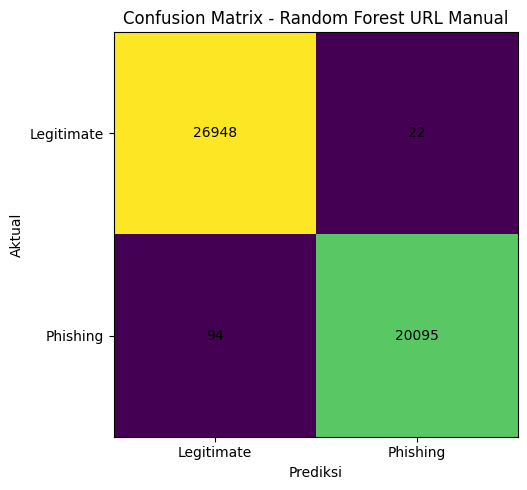

Confusion matrix disimpan di: C:\Users\ASUS\PHISHING\reports\figures\rf_url_manual_confusion_matrix.png


In [33]:
matriks_url_manual = confusion_matrix(y_test_manual, prediksi_manual)

plt.figure(figsize=(6, 5))
plt.imshow(matriks_url_manual)
plt.title("Confusion Matrix - Random Forest URL Manual")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.xticks([0, 1], ["Legitimate", "Phishing"])
plt.yticks([0, 1], ["Legitimate", "Phishing"])

for baris in range(matriks_url_manual.shape[0]):
    for kolom in range(matriks_url_manual.shape[1]):
        plt.text(
            kolom,
            baris,
            matriks_url_manual[baris, kolom],
            ha="center",
            va="center"
        )

plt.tight_layout()

lokasi_gambar_manual = direktori_project / "reports" / "figures" / "rf_url_manual_confusion_matrix.png"
plt.savefig(lokasi_gambar_manual, dpi=300)
plt.show()

print("Confusion matrix disimpan di:", lokasi_gambar_manual)

## Simpan Model URL Manual

In [34]:
lokasi_model_rf_url_manual = direktori_models / "model_rf_url_manual.pkl"
lokasi_fitur_url_manual = direktori_output / "daftar_fitur_url_manual.json"

joblib.dump(model_rf_url_manual, lokasi_model_rf_url_manual)

with open(lokasi_fitur_url_manual, "w", encoding="utf-8") as file:
    json.dump(fitur_url_only, file, indent=4, ensure_ascii=False)

print("Model URL manual disimpan di:", lokasi_model_rf_url_manual)
print("Daftar fitur URL manual disimpan di:", lokasi_fitur_url_manual)

Model URL manual disimpan di: C:\Users\ASUS\PHISHING\models\model_rf_url_manual.pkl
Daftar fitur URL manual disimpan di: C:\Users\ASUS\PHISHING\reports\outputs\daftar_fitur_url_manual.json


## Ganti Fungsi Prediksi agar Memakai Model URL Manual

In [35]:
def prediksi_url_baru_manual(url):
    data_fitur, domain, tld = ekstrak_fitur_url_baru(url)

    probabilitas = model_rf_url_manual.predict_proba(data_fitur)[0][1]
    skor_risiko = round(probabilitas * 100, 2)
    kategori_risiko = tentukan_kategori_risiko(skor_risiko)

    prediksi_target = int(probabilitas >= 0.5)

    prediksi_keterangan = {
        1: "Phishing",
        0: "Legitimate"
    }[prediksi_target]

    alasan_prediksi = buat_alasan_prediksi(
        data_fitur.iloc[0],
        tld
    )

    rekomendasi = tentukan_rekomendasi(kategori_risiko)

    hasil = {
        "url": url,
        "domain": domain,
        "tld": tld,
        "prediksi": prediksi_keterangan,
        "probabilitas_phishing": probabilitas,
        "skor_risiko": skor_risiko,
        "kategori_risiko": kategori_risiko,
        "alasan_prediksi": alasan_prediksi,
        "rekomendasi": rekomendasi
    }

    return hasil

## Uji Ulang URL Baru dengan Model Manual

In [38]:
daftar_url_uji_manual = [
    "https://www.google.com",
    "https://www.university.edu",
    "https://www.southbankmosaics.com",
    "https://www.bca.co.id",
    "https://www.tni.mil.id",
    "http://155.94.163.206/ai/?authenticated=true&account=login",
    "http://login-secure-account-update.top/verify?id=12345",
    "http://www.shaparakpayer.cf"
]

hasil_batch_url_manual = []

for url in daftar_url_uji_manual:
    hasil_batch_url_manual.append(prediksi_url_baru_manual(url))

data_hasil_batch_url_manual = pd.DataFrame(hasil_batch_url_manual)

data_hasil_batch_url_manual[[
    "url",
    "domain",
    "tld",
    "prediksi",
    "probabilitas_phishing",
    "skor_risiko",
    "kategori_risiko",
    "alasan_prediksi"
]]

,url,domain,tld,prediksi,probabilitas_phishing,skor_risiko,kategori_risiko,alasan_prediksi
0,https://www.google.com,www.google.com,com,Legitimate,0.000000,0.00,Rendah,Tidak ditemukan pola risiko besar dari fitur U...
1,https://www.university.edu,www.university.edu,edu,Legitimate,0.000000,0.00,Rendah,Tidak ditemukan pola risiko besar dari fitur U...
2,https://www.southbankmosaics.com,www.southbankmosaics.com,com,Legitimate,0.004289,0.43,Rendah,Domain lebih panjang dari pola umum.
3,https://www.bca.co.id,www.bca.co.id,id,Legitimate,0.004834,0.48,Rendah,URL memiliki jumlah subdomain yang tinggi.
4,https://www.tni.mil.id,www.tni.mil.id,id,Legitimate,0.002166,0.22,Rendah,URL memiliki jumlah subdomain yang tinggi.
5,http://155.94.163.206/ai/?authenticated=true&a...,155.94.163.206,206,Phishing,1.000000,100.00,Sangat Tinggi,URL tidak menggunakan HTTPS. Domain menggunaka...
6,http://login-secure-account-update.top/verify?...,login-secure-account-update.top,top,Phishing,1.000000,100.00,Sangat Tinggi,URL tidak menggunakan HTTPS. URL lebih panjang...
7,http://www.shaparakpayer.cf,www.shaparakpayer.cf,cf,Phishing,1.000000,100.00,Sangat Tinggi,URL tidak menggunakan HTTPS. TLD termasuk kelo...


## Simpan Hasil Prediksi Manual

In [39]:
lokasi_hasil_batch_url_manual = direktori_output / "contoh_prediksi_url_baru_model_manual.csv"

data_hasil_batch_url_manual.to_csv(lokasi_hasil_batch_url_manual, index=False)

print("Hasil prediksi URL baru model manual disimpan di:")
print(lokasi_hasil_batch_url_manual)

Hasil prediksi URL baru model manual disimpan di:
C:\Users\ASUS\PHISHING\reports\outputs\contoh_prediksi_url_baru_model_manual.csv
